In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


In [3]:
#loading the Dataset
df=pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\data-science-using-python\dirty_cafe_sales_cleaned.csv") 

In [5]:
# Display Dataset
print(df.head())
print(df.info())


  Transaction ID    Item  Quantity  Price Per Unit  Total Spent  \
0    TXN_1961373  Coffee       2.0             2.0          4.0   
1    TXN_4977031    Cake       4.0             3.0         12.0   
2    TXN_4271903  Cookie       4.0             1.0          NaN   
3    TXN_7034554   Salad       2.0             5.0         10.0   
4    TXN_3160411  Coffee       2.0             2.0          4.0   

   Payment Method  Location Transaction Date  
0             1.0  Takeaway       2023-09-08  
1             0.0  In-store       2023-05-16  
2             1.0  In-store       2023-07-19  
3             2.0  Takeaway       2023-04-27  
4             2.0  In-store       2023-06-11  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              10000 non-null  object 
 2   Quantity       

In [8]:
#Handle Missing Values
# Fill numeric columns with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical columns with mode (FIXED CODE)
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))


In [9]:
#Drop unnecessary columns (if present)
columns_to_drop = ['Transaction ID', 'Transaction Date']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

In [10]:
#Encode Categorical Variables
le = LabelEncoder()
for col in cat_cols:
    if col in df.columns:   # ensure column still exists
        df[col] = le.fit_transform(df[col])


In [11]:
#Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


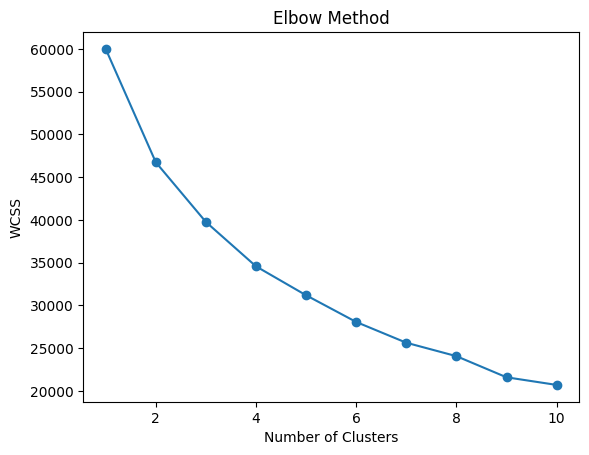

In [12]:
#Elbow Method to find optimal clusters
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [13]:
#Apply KMeans (choose K from elbow graph, here K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(scaled_data)

In [14]:
#Add cluster labels
df['Cluster'] = y_kmeans

In [15]:
# Display clustered data
print("\nClustered Data:\n", df.head())


Clustered Data:
    Item  Quantity  Price Per Unit  Total Spent  Payment Method  Location  \
0     1       2.0             2.0     4.000000             1.0         1   
1     0       4.0             3.0    12.000000             0.0         0   
2     2       4.0             1.0     8.924352             1.0         0   
3     4       2.0             5.0    10.000000             2.0         1   
4     1       2.0             2.0     4.000000             2.0         0   

   Cluster  
0        1  
1        2  
2        2  
3        0  
4        2  


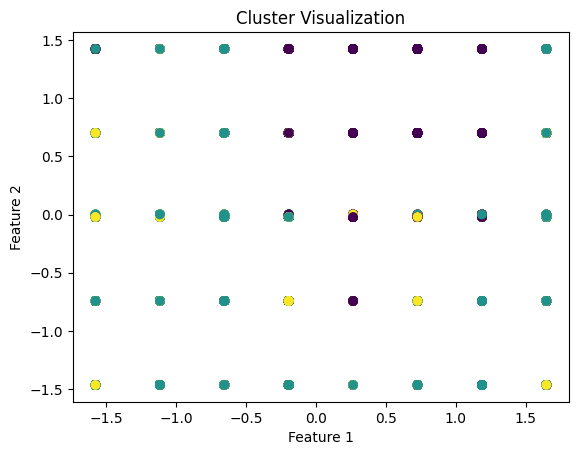

In [16]:
#Visualize Clusters (using first 2 features)
plt.figure()
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=y_kmeans)
plt.title('Cluster Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()